<a href="https://colab.research.google.com/github/defz-07/pengolahan-data/blob/main/Analisis_Data_Kualitatif_Kendala_yang_Dialami_Perawat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from wordcloud import WordCloud

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
# LOAD DATA
df = pd.read_excel('Data Kualitatif Mengenai Kendala.xlsx')
df.head()

,Kendala atau permasalahan apa yang Anda alami saat menggunakan EHR di Instalasi Rawat Inap RSA UGM? Mohon jelaskan pengalaman Anda
0,"Ketika listrik mati, untuk terhubung kembali k..."
1,Sering lola saat akses EHR
2,Kendala saat mati lampu internet eror jadi sus...
3,terkadang jika admisi pasien sudah lama mondok...
4,"Jaringan internet lemot, jika mendampingi visi..."


In [ ]:
print(df.columns)

# Ambil data pada kolom pertama
data = df[['Kendala atau permasalahan apa yang Anda alami saat menggunakan EHR di Instalasi Rawat Inap RSA UGM? Mohon jelaskan pengalaman Anda']]

# Rename kolom agar lebih mudah
data.columns = ['response']

# Tampilkan data
data.head()

# Jumlah data
print("Jumlah data:", len(data))

# Cek missing value
print("Missing value:", data.isnull().sum())

print("Jumlah data setelah cleaning:", len(data))

# Menampilkan data
for i in range(5):
    print(f"Data {i+1}:")
    print(data['response'][i])
    print()

Index(['Kendala atau permasalahan apa yang Anda alami saat menggunakan EHR di Instalasi Rawat Inap RSA UGM? Mohon jelaskan pengalaman Anda'], dtype='object')
Jumlah data: 33
Missing value: response    0
dtype: int64
Jumlah data setelah cleaning: 33
Data 1:
Ketika listrik mati, untuk terhubung kembali ke sistem membutuhkan waktu yang lama. 



Data 2:
Sering lola saat akses EHR

Data 3:
Kendala saat mati lampu internet eror jadi susah masuk akses ke EHR, atau terkadang mau login agak susah

Data 4:
terkadang jika admisi pasien sudah lama mondok, untuk admisi RM pasien tersebut sedikit lama dibuka atau loading.

Data 5:
Jaringan internet lemot, jika mendampingi visit dokter terkadang mengeluhkan jaringannya yg lama



In [ ]:
import re
import string
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = stopwords.words('indonesian')

# Daftar kosa kata yang tidak dihapus
important_words = [
    'tidak',
    'belum',
    'sulit',
    'lama',
    'lambat',
    'lemot',
    'loading',
    'error',
    'down',
    'gangguan',
    'kendala',
    'trouble',
    'jaringan',
]

factory = StemmerFactory()
stemmer = factory.create_stemmer()

normalization_dict = {
    'eror': 'error',
    'terkadang': 'kadang',
    'loadingnya': 'loading',
    'lola': 'lama',
    'ngelag': 'lemot',
    'lambat': 'lemot',
    'jaringannya': 'jaringan',
    'sinyalnya': 'sinyal',
    'trouble': 'masalah',
    'cuman': 'hanya',
    'sulit': 'susah',
    'yg': 'yang',
    'ga': 'tidak',
    'gak': 'tidak',
    'tdk': 'tidak',
}

# Stopwords removal
stop_words = [
    word for word in stop_words
    if word not in important_words
]

# Data preprocessing
def preprocess_text(text):

    # Memastikan dalam format string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove angka
    #text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Normalization
    normalized_tokens = []

    for word in tokens:
        if word in normalization_dict:
            normalized_tokens.append(
                normalization_dict[word]
            )
        else:
            normalized_tokens.append(word)

    # 8. Stopword removal
    filtered_tokens = []

    for word in normalized_tokens:
        # Pertahankan kata penting
        if word not in stop_words:
            # Hapus token sangat pendek
            if len(word) > 2:
                filtered_tokens.append(word)

    # Gabungkan kembali
    final_text = ' '.join(filtered_tokens)

    return final_text

In [ ]:
import nltk
nltk.download('punkt_tab')

# Preprocessing
data['clean_text'] = data['response'].apply(preprocess_text)

data[['response', 'clean_text']].head(33)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,response,clean_text
0,"Ketika listrik mati, untuk terhubung kembali k...",listrik mati terhubung sistem membutuhkan lama
1,Sering lola saat akses EHR,lama akses ehr
2,Kendala saat mati lampu internet eror jadi sus...,kendala mati lampu internet error susah masuk ...
3,terkadang jika admisi pasien sudah lama mondok...,kadang admisi pasien lama mondok admisi pasien...
4,"Jaringan internet lemot, jika mendampingi visi...",jaringan internet lemot mendampingi visit dokt...
5,Terkadang server trouble,kadang server
6,akun tertentu tidak bisa untuk verif icon tert...,akun tidak verif icon membutuhkan icon tolong ...
7,Saat sistem down kita susah untuk mengakses SIMRS,sistem down susah mengakses simrs
8,Kadang jaringan internet lambat sehingga saat ...,kadang jaringan internet lemot lemot
9,Jika internet down sulit untuk melihat ehr,internet down susah ehr


In [ ]:
# REMOVE EMPTY TEXT
data = data[data['clean_text'].str.strip() != '']

data = data.reset_index(drop=True)

print("Jumlah data:", len(data))

Jumlah data: 33


Word Frequency

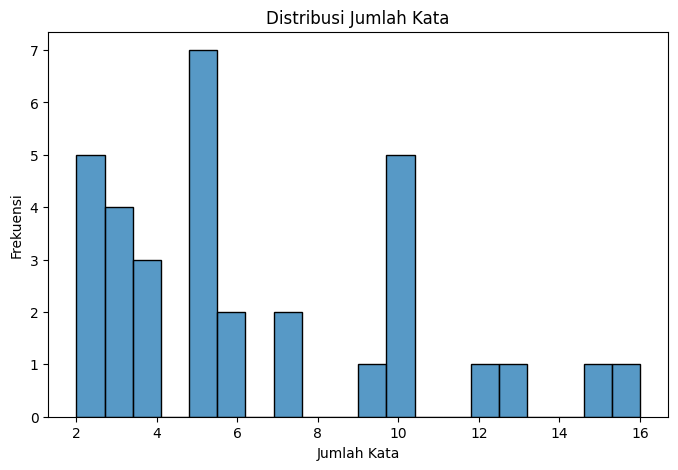

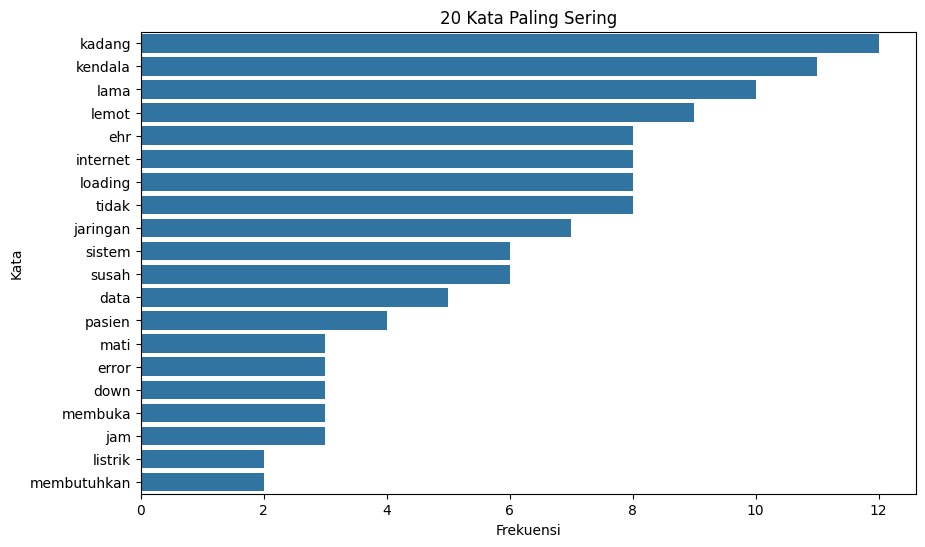

In [ ]:
data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))

# Statistik jumlah kata
data['word_count'].describe()

# DISTRIBUSI PANJANG TEKS
plt.figure(figsize=(8,5))

sns.histplot(data['word_count'], bins=20)

plt.title('Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

# GABUNGKAN SEMUA TEKS
all_text = ' '.join(data['clean_text'])

# FREKUENSI KATA
from collections import Counter

words = all_text.split()
word_freq = Counter(words)

# 20 kata paling sering
top_words = word_freq.most_common(20)

# DATAFRAME TOP WORDS
top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])

# VISUALISASI TOP WORDS
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title('20 Kata Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

In [ ]:
top_words_df[['word', 'frequency']].head(20)

,word,frequency
0,kadang,12
1,kendala,11
2,lama,10
3,lemot,9
4,ehr,8
5,internet,8
6,loading,8
7,tidak,8
8,jaringan,7
9,sistem,6


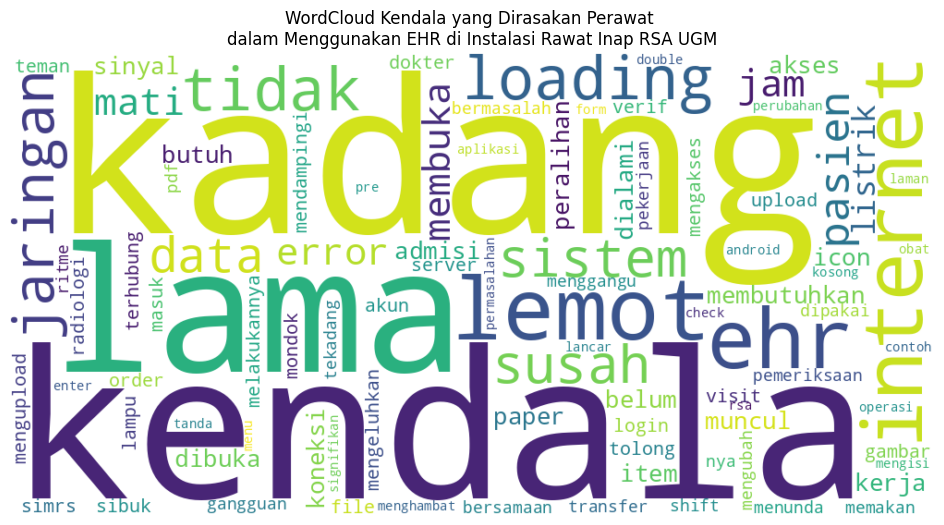

In [ ]:
# WORDCLOUD

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('WordCloud Kendala yang Dirasakan Perawat \ndalam Menggunakan EHR di Instalasi Rawat Inap RSA UGM')

plt.show()

Bigram Analysis

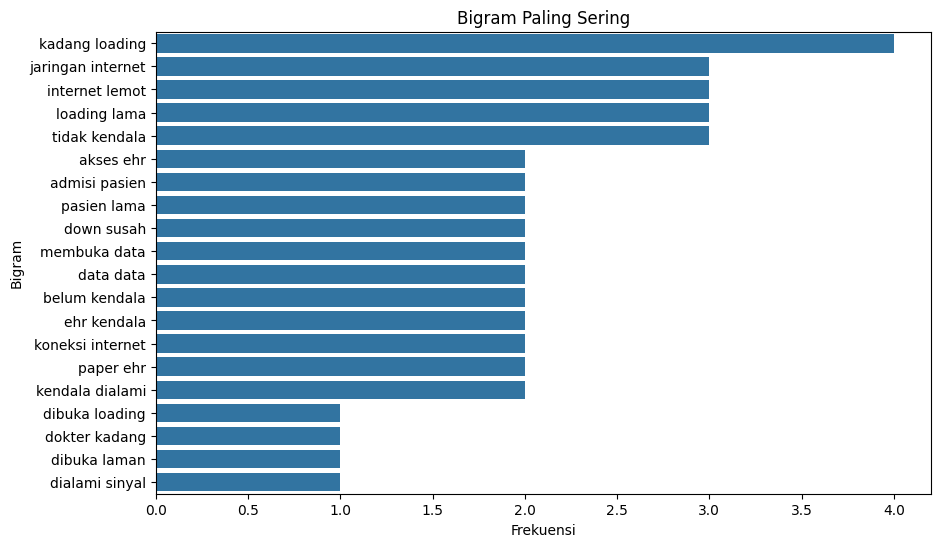

,bigram,frequency
0,kadang loading,4
1,jaringan internet,3
2,internet lemot,3
3,loading lama,3
4,tidak kendala,3
5,akses ehr,2
6,admisi pasien,2
7,pasien lama,2
8,down susah,2
9,membuka data,2


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# BIGRAM ANALYSIS
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq


# VISUALISASI BIGRAM
bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')

plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']].head(33)

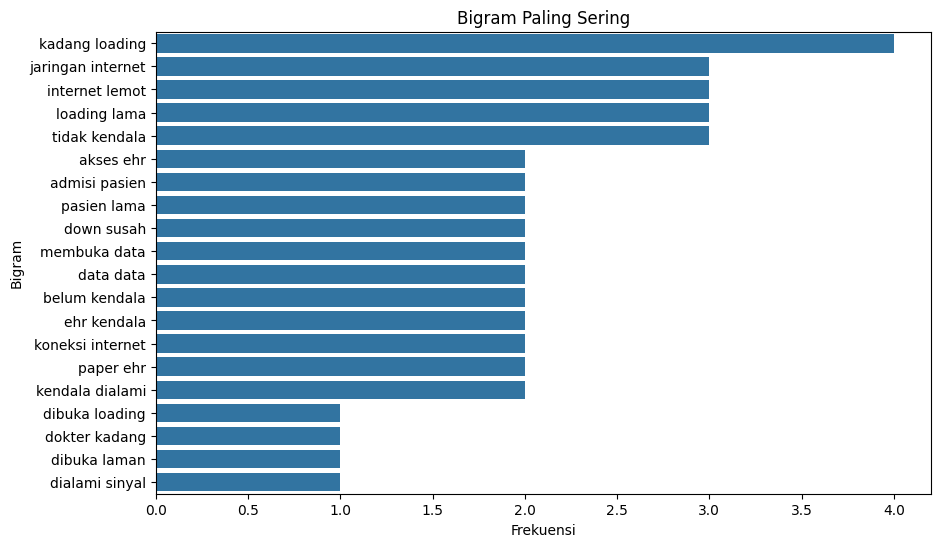

,bigram,frequency
0,kadang loading,4
1,jaringan internet,3
2,internet lemot,3
3,loading lama,3
4,tidak kendala,3
5,akses ehr,2
6,admisi pasien,2
7,pasien lama,2
8,down susah,2
9,membuka data,2


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# BIGRAM ANALYSIS
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq

# VISUALISASI BIGRAM
bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')

plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']].head(33)

TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    # Jumlah maksimal feature
    max_features=1000,

    # Gunakan unigram + bigram
    ngram_range=(1,2),

    # Minimal muncul di 1 dokumen
    min_df=1,

    # Maksimal muncul di 90% dokumen
    max_df=0.9
)
# =========================
# TF-IDF TRANSFORMATION
# =========================

X = tfidf.fit_transform(
    data['clean_text']
)
# =========================
# SHAPE MATRIX
# =========================

print(X.shape)
# =========================
# FEATURE NAMES
# =========================

feature_names = tfidf.get_feature_names_out()

print(feature_names)

(33, 250)
['admisi' 'admisi pasien' 'akses' 'akses ehr' 'akun' 'akun tidak'
 'android' 'android tidak' 'aplikasi' 'aplikasi error' 'belum'
 'belum kendala' 'bermasalah' 'bermasalah menunda' 'bersamaan' 'butuh'
 'butuh muncul' 'check' 'check obat' 'contoh' 'contoh peralihan' 'data'
 'data butuh' 'data data' 'data pasien' 'dialami' 'dialami ehr'
 'dialami sinyal' 'dibuka' 'dibuka laman' 'dibuka loading' 'dipakai'
 'dipakai bersamaan' 'dokter' 'dokter kadang' 'double' 'double check'
 'down' 'down jaringan' 'down susah' 'ehr' 'ehr contoh' 'ehr down'
 'ehr kadang' 'ehr kendala' 'enter' 'error' 'error dibuka' 'error susah'
 'file' 'file gambar' 'form' 'form pre' 'gambar' 'gambar radiologi'
 'gangguan' 'gangguan menggangu' 'icon' 'icon membutuhkan' 'icon tolong'
 'internet' 'internet down' 'internet error' 'internet kadang'
 'internet lemot' 'internet susah' 'item' 'item order' 'jam' 'jam jam'
 'jam lemot' 'jam sibuk' 'jaringan' 'jaringan bermasalah'
 'jaringan internet' 'jaringan lama' 'jari

In [ ]:
# =========================
# TF-IDF DATAFRAME
# =========================

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df.head()

,admisi,admisi pasien,akses,akses ehr,akun,akun tidak,android,android tidak,aplikasi,aplikasi error,...,tolong,tolong teman,transfer,transfer pasien,upload,upload pemeriksaan,verif,verif icon,visit,visit dokter
0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,0.000000,0.000000,0.489055,0.489055,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,0.000000,0.000000,0.203159,0.203159,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,0.408272,0.408272,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.253891,0.253891


In [ ]:
# =========================
# RATA-RATA TF-IDF
# =========================

mean_tfidf = tfidf_df.mean().sort_values(
    ascending=False
)

print(mean_tfidf.head(15))

lemot             0.074157
lama              0.068248
kadang            0.067233
loading           0.065294
kendala           0.064298
tidak             0.052589
ehr               0.047797
jaringan          0.046769
internet          0.046016
sistem            0.045486
loading lama      0.042433
susah             0.035951
tidak kendala     0.031554
kadang loading    0.030968
data              0.030125
dtype: float64


Sentiment Analysis (optional)

In [ ]:
# =========================
# DOWNLOAD INSET LEXICON
# =========================

!wget https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv
!wget https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv

--2026-05-21 12:50:21--  https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41462 (40K) [text/plain]
Saving to: ‘positive.tsv’

positive.tsv        100%[===================>]  40.49K  --.-KB/s    in 0.008s  

2026-05-21 12:50:22 (5.09 MB/s) - ‘positive.tsv’ saved [41462/41462]

--2026-05-21 12:50:22--  https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82788 (81K) [text/plain]
Saving to: ‘negative.tsv’


In [ ]:
import pandas as pd

# LOAD POSITIVE LEXICON
positive_df = pd.read_csv(
    'positive.tsv',
    sep='\t'
)

positive_df.head()

# LOAD NEGATIVE LEXICON
negative_df = pd.read_csv(
    'negative.tsv',
    sep='\t'
)

negative_df.head()

# POSITIVE DICTIONARY
positive_dict = dict(zip(
    positive_df['word'],
    positive_df['weight']
))

# NEGATIVE DICTIONARY
negative_dict = dict(zip(
    negative_df['word'],
    negative_df['weight']
))

In [ ]:
def calculate_sentiment(data):
    words = data.split()
    score = 0
    for word in words:
        # Positive score
        if word in positive_dict:
            score += positive_dict[word]
        # Negative score
        elif word in negative_dict:
            score += negative_dict[word]
    return score

# FUNCTION LABELING
def sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

# HITUNG SENTIMENT SCORE
data['sentiment_score'] = data['clean_text'].apply(calculate_sentiment)

# BUAT LABEL
data['sentiment'] = data['sentiment_score'].apply(sentiment_label)

# HASIL LABELING
data[[
    'response',
    'clean_text',
    'sentiment_score',
    'sentiment'
]].head(33)

,response,clean_text,sentiment_score,sentiment
0,"Ketika listrik mati, untuk terhubung kembali k...",listrik mati terhubung sistem membutuhkan lama,-4,negative
1,Sering lola saat akses EHR,lama akses ehr,-2,negative
2,Kendala saat mati lampu internet eror jadi sus...,kendala mati lampu internet error susah masuk ...,-1,negative
3,terkadang jika admisi pasien sudah lama mondok...,kadang admisi pasien lama mondok admisi pasien...,-5,negative
4,"Jaringan internet lemot, jika mendampingi visi...",jaringan internet lemot mendampingi visit dokt...,0,neutral
5,Terkadang server trouble,kadang server,3,positive
6,akun tertentu tidak bisa untuk verif icon tert...,akun tidak verif icon membutuhkan icon tolong ...,-2,negative
7,Saat sistem down kita susah untuk mengakses SIMRS,sistem down susah mengakses simrs,-10,negative
8,Kadang jaringan internet lambat sehingga saat ...,kadang jaringan internet lemot lemot,-4,negative
9,Jika internet down sulit untuk melihat ehr,internet down susah ehr,-6,negative


In [ ]:
# DISTRIBUSI LABEL
data['sentiment'].value_counts()

,count
sentiment,
negative,23
neutral,5
positive,5


In [ ]:
# =========================
# SAVE PREPROCESSED DATA
# =========================

data.to_excel('hasil_preprocessing.xlsx', index=False)

In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(
    ngram_range=(1,2)
)

X = tfidf.fit_transform(
    data['clean_text']
)
# =========================
# TF-IDF SCORE
# =========================

mean_tfidf = np.mean(
    X.toarray(),
    axis=0
)

tfidf_df = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'score': mean_tfidf
})

tfidf_df = tfidf_df.sort_values(
    by='score',
    ascending=False
)

tfidf_df.head(20)

,word,score
86,kendala,0.080689
122,loading,0.062503
102,lama,0.060199
41,ehr,0.054275
108,lambat,0.053738
243,tidak,0.051496
233,terkadang,0.047271
75,jaringan,0.045427
62,internet,0.044172
123,loading lama,0.040804


In [ ]:
# themes = pd.DataFrame({
    #'Theme': [
        #'Kendala Jaringan',
        #'Performa Sistem',
        #'System Reliability',
        #'Kendala Akses',
        #'Kendala Fitur',
        #'Adaptasi Sistem'
    #],

    #'Keywords': [
        #'internet, jaringan, sinyal',
        #'loading, lambat, lemot',
        #'error, down, trouble',
        #'login, akses',
        #'upload, pdf, android',
        #'paper, peralihan'
    #]
#})